/Users/atharvadeshpande/Exoplanet_Characterisation/exo_cnn/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Searching MAST archive for TIC 105706043...
Found 11 available observations. Downloading the first one...
Cleaning and flattening the stellar data...
Real TESS background noise successfully ingested.


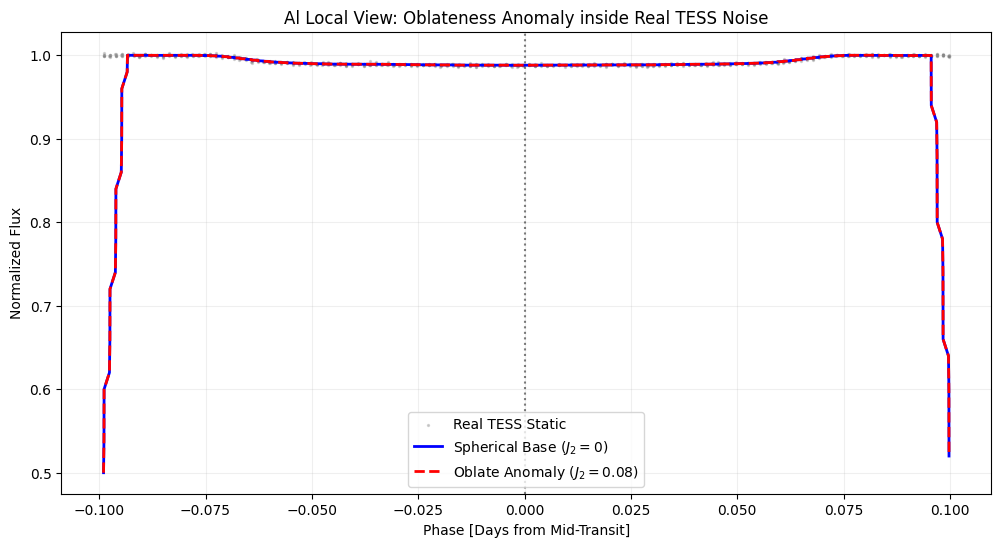

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.components.data_simulator import EmpiricalSimulator

# 1. Initialize the new Empirical Simulator
sim = EmpiricalSimulator()

# 2. Fetch the real TESS background noise from the MAST archive
# (This might take ~10 seconds depending on your internet connection)
sim.fetch_tess_noise_floor(tic_id="TIC 105706043")
# 3. Generate two Local Views: One perfect sphere, one oblate planet
# We will use a Jupiter-sized planet (rp_rs=0.1) on a tight orbit (period=3.5)
phase_spherical, flux_spherical = sim.get_local_view(
    period=3.5, rp_rs=0.1, a_rs=8.0, inc=89.5, j2=0.0   # Sphere
)

phase_oblate, flux_oblate = sim.get_local_view(
    period=3.5, rp_rs=0.1, a_rs=8.0, inc=89.5, j2=0.08  # Highly oblate
)

# 4. Plot the comparison (Mimicking your Tri-Input Local View)
plt.figure(figsize=(12, 6))

# Plot the real TESS data points with the injected signals
plt.scatter(phase_spherical, flux_spherical, s=2, color='gray', alpha=0.3, label='Real TESS Static')

# Overlay the smoothed shapes to see the physical difference
# We use a moving average to highlight the underlying transit shape
window = 50
smoothed_spherical = np.convolve(flux_spherical, np.ones(window)/window, mode='same')
smoothed_oblate = np.convolve(flux_oblate, np.ones(window)/window, mode='same')

plt.plot(phase_spherical, smoothed_spherical, color='blue', linewidth=2, label='Spherical Base ($J_2=0$)')
plt.plot(phase_oblate, smoothed_oblate, color='red', linewidth=2, linestyle='--', label='Oblate Anomaly ($J_2=0.08$)')

plt.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.title('Al Local View: Oblateness Anomaly inside Real TESS Noise')
plt.xlabel('Phase [Days from Mid-Transit]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [2]:
import os

# 1. Generate 5,000 samples (This will take a few minutes)
# We use 5,000 instead of 10,000 to save your laptop's CPU, as the empirical 
# PyTransit integration is much heavier than the toy model.
X_data, y_data = sim.generate_dataset(num_samples=5000, n_features=250)

# 2. Split into Training and Testing sets (80/20 split)
split_idx = int(0.8 * len(X_data))

X_train, X_test = X_data[:split_idx], X_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# 3. Save to your data/synthetic/ folder
save_dir = "../data/synthetic"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "X_test.npy"), X_test)
np.save(os.path.join(save_dir, "y_train.npy"), y_train)
np.save(os.path.join(save_dir, "y_test.npy"), y_test)

print(f"\nEmpirical Dataset successfully saved to {save_dir}!")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")

Generating 5000 samples using empirical TESS noise...


100%|██████████| 5000/5000 [00:06<00:00, 719.83it/s]


Empirical Dataset successfully saved to ../data/synthetic!
Training shapes: X=(4000, 250), y=(4000,)
